##IMPORTAÇÃO E CARREGAMENTO DOS DADOS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
d_banco = pd.read_csv('/content/cs-training.csv')

##EXPLORAÇÃO DOS DADOS

In [ ]:
d_banco.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
d_banco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [ ]:
d_banco.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [ ]:
d_banco.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


##LIMPEZA E TRATAMENTO DOS DADOS

In [ ]:
if 'Unnamed: 0' in d_banco.columns:

    d_banco = d_banco.drop(columns=['Unnamed: 0'])

In [ ]:
d_banco['MonthlyIncome_missing'] = d_banco['MonthlyIncome'].isnull().astype(int)

In [ ]:
mediana_renda = d_banco['MonthlyIncome'].median()
d_banco['MonthlyIncome'] = d_banco['MonthlyIncome'].fillna(mediana_renda)

In [ ]:
d_banco['NumberOfDependents'] = d_banco['NumberOfDependents'].fillna(0).astype('int64')


In [ ]:
d_banco.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


##ANÁLISE DO PERFIL DO INADIMPLENTE

In [ ]:
# Visão Geral

print("--- Proporção Geral de Inadimplência (%) ---")
print(d_banco['SeriousDlqin2yrs'].value_counts(normalize=True) * 100)

--- Proporção Geral de Inadimplência (%) ---
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


In [ ]:
# PERGUNTA 1: Qual o perfil demográfico (idade, dependentes) do cliente inadimplente?

print("\n--- Idade Média por Status de Pagamento ---")
print(d_banco.groupby('SeriousDlqin2yrs')['age'].mean())

print("\n--- Nº Médio de Dependentes por Status de Pagamento ---")
print(d_banco.groupby('SeriousDlqin2yrs')['NumberOfDependents'].mean())



--- Idade Média por Status de Pagamento ---
SeriousDlqin2yrs
0    52.751375
1    45.926591
Name: age, dtype: float64

--- Nº Médio de Dependentes por Status de Pagamento ---
SeriousDlqin2yrs
0    0.723527
1    0.931279
Name: NumberOfDependents, dtype: float64


In [ ]:
# PERGUNTA 2: O histórico de atrasos passados prevê inadimplência futura?

print("\n--- Atrasos Curtos (30-59 dias) por Status ---")
print(d_banco.groupby('SeriousDlqin2yrs')['NumberOfTime30-59DaysPastDueNotWorse'].mean())

print("\n--- Atrasos Médios (60-89 dias) por Status ---")
print(d_banco.groupby('SeriousDlqin2yrs')['NumberOfTime60-89DaysPastDueNotWorse'].mean())

print("\n--- Atrasos Longos (90+ dias) por Status ---")
print(d_banco.groupby('SeriousDlqin2yrs')['NumberOfTimes90DaysLate'].mean())



--- Atrasos Curtos (30-59 dias) por Status ---
SeriousDlqin2yrs
0    0.280109
1    2.388490
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

--- Atrasos Médios (60-89 dias) por Status ---
SeriousDlqin2yrs
0    0.126666
1    1.828047
Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: float64

--- Atrasos Longos (90+ dias) por Status ---
SeriousDlqin2yrs
0    0.135225
1    2.091362
Name: NumberOfTimes90DaysLate, dtype: float64


In [ ]:
# PERGUNTA 3: O uso do limite de crédito disponível está associado a maior risco?

print("\n--- Uso do Limite de Crédito (Mediana) por Status ---")
print(d_banco.groupby('SeriousDlqin2yrs')['RevolvingUtilizationOfUnsecuredLines'].median())



--- Uso do Limite de Crédito (Mediana) por Status ---
SeriousDlqin2yrs
0    0.133288
1    0.838853
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [ ]:
# PERGUNTA 4: A renda mensal, isoladamente, é um bom preditor de inadimplência?

print("\n--- Mediana de Renda por Status de Pagamento ---")
print(d_banco.groupby('SeriousDlqin2yrs')['MonthlyIncome'].median())


--- Mediana de Renda por Status de Pagamento ---
SeriousDlqin2yrs
0    5400.0
1    5240.0
Name: MonthlyIncome, dtype: float64


In [ ]:
# PERGUNTA 5: Clientes sem informação de renda(MonthlyIncome_missing) têm comportamento de risco diferente?

print("\n--- Taxa de Inadimplência (%) por Renda Ausente ---")
print(d_banco.groupby('MonthlyIncome_missing')['SeriousDlqin2yrs'].mean() * 100)


--- Taxa de Inadimplência (%) por Renda Ausente ---
MonthlyIncome_missing
0    6.948590
1    5.613669
Name: SeriousDlqin2yrs, dtype: float64


##VISUALIZAÇÃO DOS DADOS


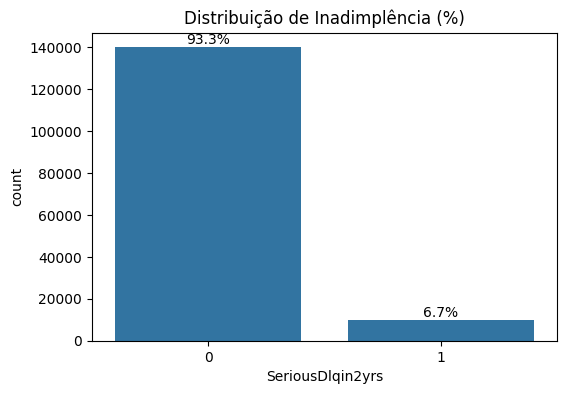

In [ ]:
# --- Visão Geral: Distribuição de Inadimplência ---
plt.figure(figsize=(6,4))
ax = sns.countplot(x='SeriousDlqin2yrs', data=d_banco)
total = len(d_banco)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.title('Distribuição de Inadimplência (%)')
plt.show()


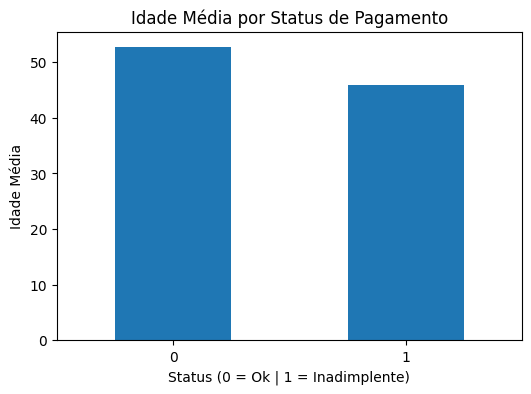

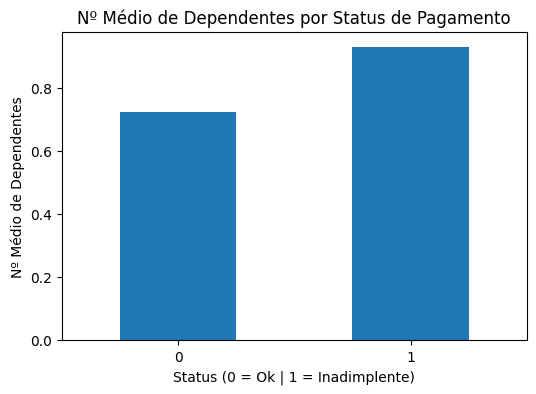

In [ ]:
# PERGUNTA 1: Perfil demográfico

plt.figure(figsize=(6,4))
d_banco.groupby('SeriousDlqin2yrs')['age'].mean().plot(kind='bar')
plt.title('Idade Média por Status de Pagamento')
plt.xlabel('Status (0 = Ok | 1 = Inadimplente)')
plt.ylabel('Idade Média')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6,4))
d_banco.groupby('SeriousDlqin2yrs')['NumberOfDependents'].mean().plot(kind='bar')
plt.title('Nº Médio de Dependentes por Status de Pagamento')
plt.xlabel('Status (0 = Ok | 1 = Inadimplente)')
plt.ylabel('Nº Médio de Dependentes')
plt.xticks(rotation=0)
plt.show()

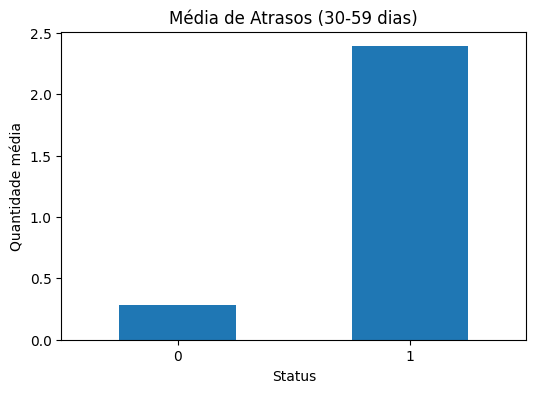

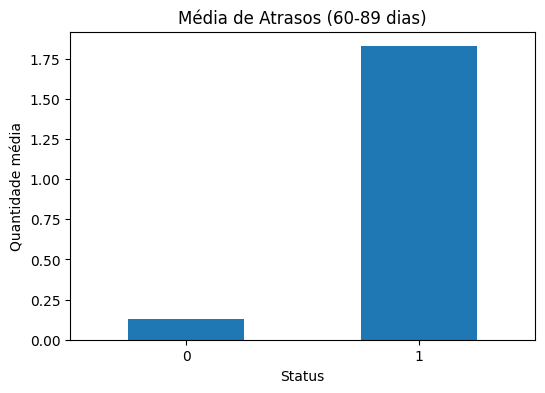

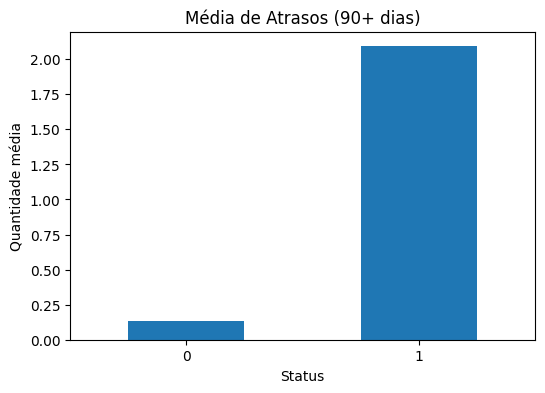

In [ ]:
# PERGUNTA 2: Histórico de atrasos

plt.figure(figsize=(6,4))
d_banco.groupby('SeriousDlqin2yrs')['NumberOfTime30-59DaysPastDueNotWorse'].mean().plot(kind='bar')
plt.title('Média de Atrasos (30-59 dias)')
plt.xlabel('Status')
plt.ylabel('Quantidade média')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6,4))
d_banco.groupby('SeriousDlqin2yrs')['NumberOfTime60-89DaysPastDueNotWorse'].mean().plot(kind='bar')
plt.title('Média de Atrasos (60-89 dias)')
plt.xlabel('Status')
plt.ylabel('Quantidade média')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6,4))
d_banco.groupby('SeriousDlqin2yrs')['NumberOfTimes90DaysLate'].mean().plot(kind='bar')
plt.title('Média de Atrasos (90+ dias)')
plt.xlabel('Status')
plt.ylabel('Quantidade média')
plt.xticks(rotation=0)
plt.show()


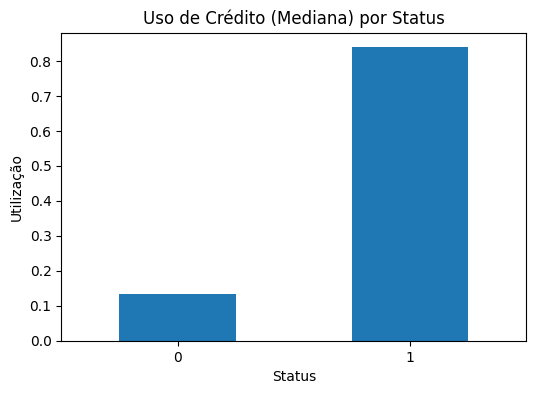

In [ ]:
# PERGUNTA 3: Uso do limite de crédito

plt.figure(figsize=(6,4))
d_banco.groupby('SeriousDlqin2yrs')['RevolvingUtilizationOfUnsecuredLines'].median().plot(kind='bar')
plt.title('Uso de Crédito (Mediana) por Status')
plt.xlabel('Status')
plt.ylabel('Utilização')
plt.xticks(rotation=0)
plt.show()


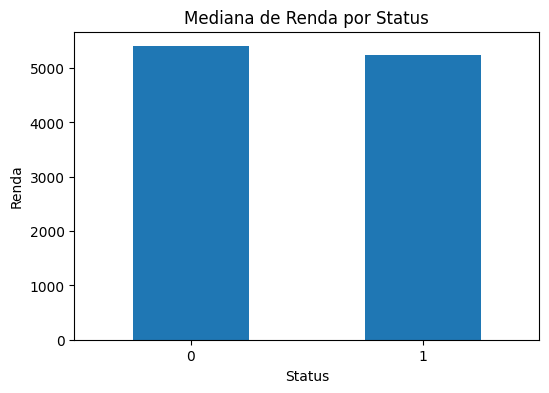

In [ ]:
# PERGUNTA 4: Renda mensal

plt.figure(figsize=(6,4))
d_banco.groupby('SeriousDlqin2yrs')['MonthlyIncome'].median().plot(kind='bar')
plt.title('Mediana de Renda por Status')
plt.xlabel('Status')
plt.ylabel('Renda')
plt.xticks(rotation=0)
plt.show()


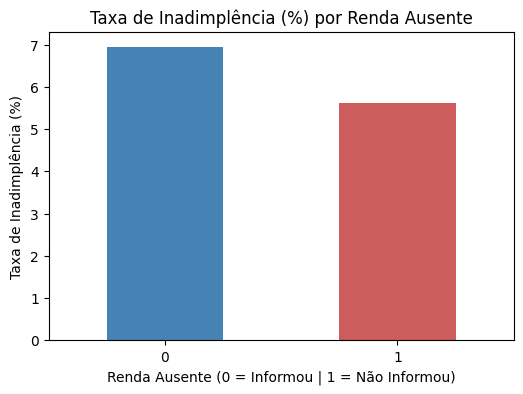

In [ ]:
# PERGUNTA 5: Renda ausente

plt.figure(figsize=(6,4))
(d_banco.groupby('MonthlyIncome_missing')['SeriousDlqin2yrs'].mean() * 100).plot(kind='bar', color=['steelblue','indianred'])
plt.title('Taxa de Inadimplência (%) por Renda Ausente')
plt.xlabel('Renda Ausente (0 = Informou | 1 = Não Informou)')
plt.ylabel('Taxa de Inadimplência (%)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
d_banco.to_csv('banco_horizonte_limpo.csv', index=False)